# Data Collection
This notebook handles loading the raw drug review data and filtering it for pain-related conditions and medications.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Raw Data

In [2]:
# Define data paths (CSV format, not TSV)
train_data_path = '../data/raw/drugsComTrain_raw.csv'
test_data_path = '../data/raw/drugsComTest_raw.csv'

try:
    # Load train data
    print("Loading training dataset...")
    df_train = pd.read_csv(train_data_path)
    print(f"✓ Training dataset loaded successfully!")
    print(f"  Shape: {df_train.shape}")
    print(f"  Total records: {len(df_train):,}")
    
    # Load test data
    print("\nLoading test dataset...")
    df_test = pd.read_csv(test_data_path)
    print(f"✓ Test dataset loaded successfully!")
    print(f"  Shape: {df_test.shape}")
    print(f"  Total records: {len(df_test):,}")
    
    print(f"\n{'='*60}")
    print(f"Total records across both datasets: {len(df_train) + len(df_test):,}")
    print(f"{'='*60}")
    
except FileNotFoundError as e:
    print(f"Error: Could not find data file - {e}")
    print("Please ensure the CSV files are in the correct location.")
except Exception as e:
    print(f"Error loading data: {e}")

Loading training dataset...


✓ Training dataset loaded successfully!
  Shape: (161297, 7)
  Total records: 161,297

Loading test dataset...
✓ Test dataset loaded successfully!
  Shape: (53766, 7)
  Total records: 53,766

Total records across both datasets: 215,063


## 3. Explore Dataset Structure

In [3]:
# Display first few rows from train dataset
print("First 5 rows of the training dataset:")
display(df_train.head())

# Display dataset information
print("\nTraining Dataset Information:")
df_train.info()

# Display statistical summary
print("\nStatistical Summary:")
display(df_train.describe())

# Check column names
print("\nColumn Names:")
print(df_train.columns.tolist())

# Expected columns: uniqueID, drugName, condition, review, rating, date, usefulCount
expected_cols = ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']
if all(col in df_train.columns for col in expected_cols):
    print("\n✓ All expected columns present!")
else:
    print("\n⚠ Warning: Some expected columns are missing!")

First 5 rows of the training dataset:


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil""",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of Intuniv. We became concerned when he began this la...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, which had 21 pill cycle, and was very happy- very li...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth control. I&#039;m glad I went with the patch, I h...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around. I feel healthier, I&#039;m excelling at my job ...",9,27-Nov-16,37



Training Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   uniqueID     161297 non-null  int64
 1   drugName     161297 non-null  str  
 2   condition    160398 non-null  str  
 3   review       161297 non-null  str  
 4   rating       161297 non-null  int64
 5   date         161297 non-null  str  
 6   usefulCount  161297 non-null  int64
dtypes: int64(3), str(4)
memory usage: 8.6 MB

Statistical Summary:


,uniqueID,rating,usefulCount
count,161297.000000,161297.000000,161297.000000
mean,115923.585305,6.994377,28.004755
std,67004.445170,3.272329,36.403742
min,2.000000,1.000000,0.000000
25%,58063.000000,5.000000,6.000000
50%,115744.000000,8.000000,16.000000
75%,173776.000000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000



Column Names:
['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']

✓ All expected columns present!


## 4. Data Validation

In [4]:
# Check for missing values in train dataset
print("Missing Values in Training Dataset:")
missing_train = df_train.isnull().sum()
print(missing_train)
print(f"\nTotal missing values: {missing_train.sum()}")

# Check for missing values in test dataset
print("\nMissing Values in Test Dataset:")
missing_test = df_test.isnull().sum()
print(missing_test)
print(f"\nTotal missing values: {missing_test.sum()}")

# Check for duplicates
print(f"\n{'='*60}")
print("Duplicate Check:")
print(f"Training duplicates (based on uniqueID): {df_train['uniqueID'].duplicated().sum()}")
print(f"Test duplicates (based on uniqueID): {df_test['uniqueID'].duplicated().sum()}")
print(f"{'='*60}")

Missing Values in Training Dataset:
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

Total missing values: 899

Missing Values in Test Dataset:
uniqueID         0
drugName         0
condition      295
review           0
rating           0
date             0
usefulCount      0
dtype: int64

Total missing values: 295

Duplicate Check:
Training duplicates (based on uniqueID): 0
Test duplicates (based on uniqueID): 0


## 5. Define Pain Condition and Medication Filters

In [5]:
# Define pain-related conditions
pain_conditions = [
    'headache', 'migraine', 'back pain', 'arthritis', 'sciatica', 
    'fibromyalgia', 'toothache', 'neck pain', 'joint pain', 
    'osteoarthritis', 'rheumatoid arthritis', 'chronic pain', 
    'neuropathic pain', 'muscle pain'
]

# Define pain medications
pain_medications = [
    'ibuprofen', 'acetaminophen', 'naproxen', 'aspirin', 'diclofenac', 
    'tramadol', 'hydrocodone', 'oxycodone', 'tylenol', 'advil', 
    'aleve', 'motrin', 'celebrex', 'meloxicam', 'indomethacin'
]

print(f"Pain conditions to filter: {len(pain_conditions)}")
print(f"Pain medications to filter: {len(pain_medications)}")
print(f"\nConditions: {', '.join(pain_conditions)}")
print(f"\nMedications: {', '.join(pain_medications)}")

Pain conditions to filter: 14
Pain medications to filter: 15

Conditions: headache, migraine, back pain, arthritis, sciatica, fibromyalgia, toothache, neck pain, joint pain, osteoarthritis, rheumatoid arthritis, chronic pain, neuropathic pain, muscle pain

Medications: ibuprofen, acetaminophen, naproxen, aspirin, diclofenac, tramadol, hydrocodone, oxycodone, tylenol, advil, aleve, motrin, celebrex, meloxicam, indomethacin


## 6. Filter Dataset with AND Logic

In [6]:
# Create regex patterns
condition_pattern = '|'.join(pain_conditions)
medication_pattern = '|'.join(pain_medications)

print("Filtering training dataset...")
# Filter train dataset - BOTH condition AND medication must match
train_condition_mask = df_train['condition'].str.contains(condition_pattern, case=False, na=False, regex=True)
train_drug_mask = df_train['drugName'].str.contains(medication_pattern, case=False, na=False, regex=True)
filtered_train = df_train[train_condition_mask & train_drug_mask].copy()

print(f"✓ Training: {len(df_train):,} → {len(filtered_train):,} records ({(len(filtered_train)/len(df_train))*100:.2f}% retained)")

print("\nFiltering test dataset...")
# Filter test dataset - BOTH condition AND medication must match
test_condition_mask = df_test['condition'].str.contains(condition_pattern, case=False, na=False, regex=True)
test_drug_mask = df_test['drugName'].str.contains(medication_pattern, case=False, na=False, regex=True)
filtered_test = df_test[test_condition_mask & test_drug_mask].copy()

print(f"✓ Test: {len(df_test):,} → {len(filtered_test):,} records ({(len(filtered_test)/len(df_test))*100:.2f}% retained)")

# Combine train and test datasets
print("\nCombining filtered datasets...")
filtered_df = pd.concat([filtered_train, filtered_test], ignore_index=True)

print(f"\n{'='*60}")
print(f"Combined filtered dataset: {len(filtered_df):,} total records")
print(f"{'='*60}")

Filtering training dataset...


✓ Training: 161,297 → 1,849 records (1.15% retained)

Filtering test dataset...
✓ Test: 53,766 → 624 records (1.16% retained)

Combining filtered datasets...

Combined filtered dataset: 2,473 total records


## 7. Data Visualizations

/var/folders/lg/85nj4sds07qf3p5frkrx607w0000gn/T/ipykernel_2620/3360374862.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_df['year'] = pd.to_datetime(filtered_df['date'], errors='coerce').dt.year


Visualizations saved to: ../data/filtered/data_visualizations.png


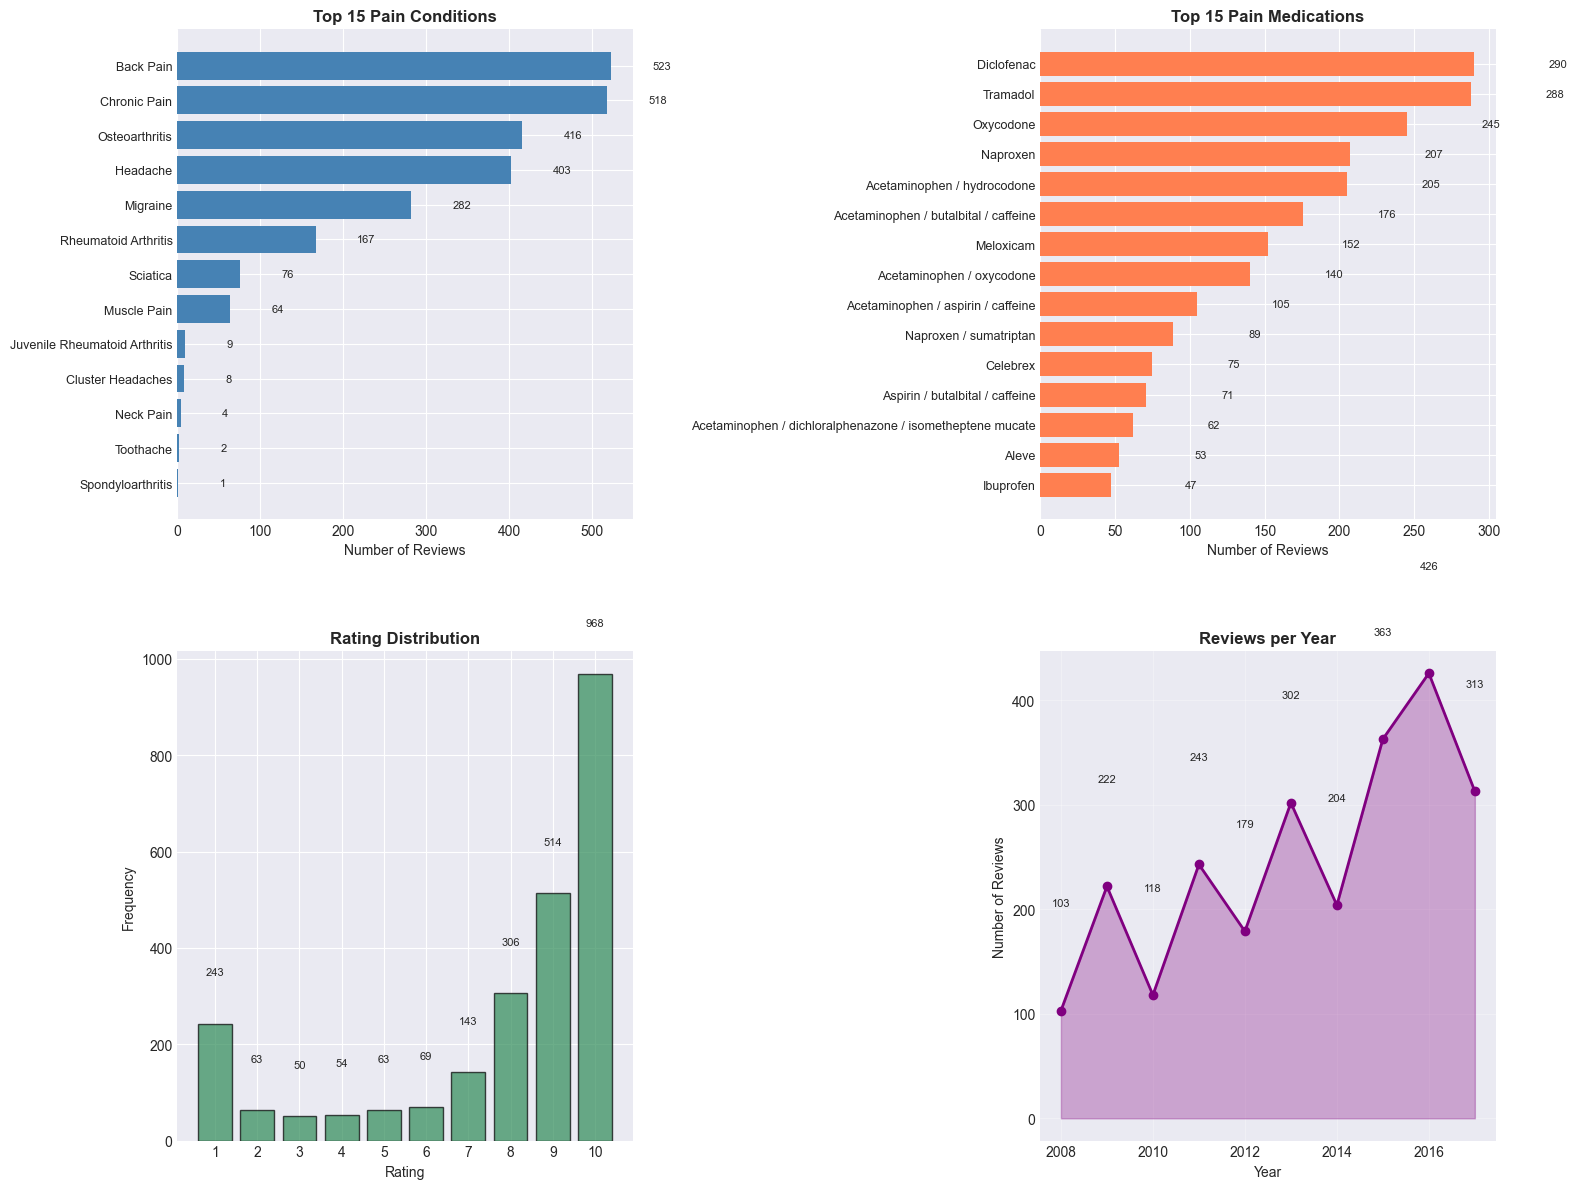

In [7]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 15 Conditions
top_conditions = filtered_df['condition'].value_counts().head(15)
axes[0, 0].barh(range(len(top_conditions)), top_conditions.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_conditions)))
axes[0, 0].set_yticklabels(top_conditions.index, fontsize=9)
axes[0, 0].set_xlabel('Number of Reviews', fontsize=10)
axes[0, 0].set_title('Top 15 Pain Conditions', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
for i, v in enumerate(top_conditions.values):
    axes[0, 0].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# 2. Top 15 Medications
top_drugs = filtered_df['drugName'].value_counts().head(15)
axes[0, 1].barh(range(len(top_drugs)), top_drugs.values, color='coral')
axes[0, 1].set_yticks(range(len(top_drugs)))
axes[0, 1].set_yticklabels(top_drugs.index, fontsize=9)
axes[0, 1].set_xlabel('Number of Reviews', fontsize=10)
axes[0, 1].set_title('Top 15 Pain Medications', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
for i, v in enumerate(top_drugs.values):
    axes[0, 1].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# 3. Rating Distribution
rating_counts = filtered_df['rating'].value_counts().sort_index()
axes[1, 0].bar(rating_counts.index, rating_counts.values, color='seagreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Rating', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(1, 11))
for i, v in enumerate(rating_counts.values):
    axes[1, 0].text(rating_counts.index[i], v + 100, f'{v:,}', ha='center', fontsize=8)

# 4. Reviews per Year
try:
    # Try to parse dates and extract year
    filtered_df['year'] = pd.to_datetime(filtered_df['date'], errors='coerce').dt.year
    year_counts = filtered_df['year'].value_counts().sort_index().dropna()
    
    if len(year_counts) > 0:
        axes[1, 1].plot(year_counts.index, year_counts.values, marker='o', linewidth=2, markersize=6, color='purple')
        axes[1, 1].fill_between(year_counts.index, year_counts.values, alpha=0.3, color='purple')
        axes[1, 1].set_xlabel('Year', fontsize=10)
        axes[1, 1].set_ylabel('Number of Reviews', fontsize=10)
        axes[1, 1].set_title('Reviews per Year', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        for x, y in zip(year_counts.index, year_counts.values):
            axes[1, 1].text(x, y + 100, f'{int(y):,}', ha='center', fontsize=8)
    else:
        axes[1, 1].text(0.5, 0.5, 'No valid date data available', 
                       ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
        axes[1, 1].set_title('Reviews per Year', fontsize=12, fontweight='bold')
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f'Error parsing dates:\n{str(e)}', 
                   ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=10)
    axes[1, 1].set_title('Reviews per Year', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/filtered/data_visualizations.png', dpi=150, bbox_inches='tight')
print("Visualizations saved to: ../data/filtered/data_visualizations.png")
plt.show()

## 8. Validate Filtered Data

In [8]:
# Check for missing values in filtered dataset
print("Missing Values in Filtered Dataset:")
missing_filtered = filtered_df.isnull().sum()
print(missing_filtered)
print(f"\nTotal missing values: {missing_filtered.sum()}")
print(f"Percentage missing: {(missing_filtered.sum() / (len(filtered_df) * len(filtered_df.columns))) * 100:.2f}%")

# Check for duplicates in combined dataset
print(f"\n{'='*60}")
duplicates = filtered_df.duplicated(subset=['uniqueID']).sum()
print(f"Duplicate records (based on uniqueID): {duplicates}")
if duplicates > 0:
    print("⚠ Warning: Duplicates found! Consider removing them.")
    # Remove duplicates if found
    filtered_df = filtered_df.drop_duplicates(subset=['uniqueID'], keep='first')
    print(f"✓ Duplicates removed. New count: {len(filtered_df):,}")
else:
    print("✓ No duplicates found!")
print(f"{'='*60}")

# Check data types
print("\nData Types:")
print(filtered_df.dtypes)

Missing Values in Filtered Dataset:
uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
year           0
dtype: int64

Total missing values: 0
Percentage missing: 0.00%

Duplicate records (based on uniqueID): 0
✓ No duplicates found!

Data Types:
uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
year           int32
dtype: object


## 9. Save Filtered Data

In [9]:
# Define output path
output_path = '../data/filtered/pain_meds_filtered.csv'

# Create directory if it doesn't exist
output_dir = Path(output_path).parent
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory created/verified: {output_dir}")

try:
    # Save to CSV
    filtered_df.to_csv(output_path, index=False)
    print(f"\n✓ Filtered data saved successfully to: {output_path}")
    
    # Verify file was created
    if Path(output_path).exists():
        file_size = Path(output_path).stat().st_size / (1024 * 1024)  # Size in MB
        print(f"  File size: {file_size:.2f} MB")
    else:
        print("⚠ Warning: File was not created!")
except Exception as e:
    print(f"Error saving file: {e}")

Output directory created/verified: ../data/filtered

✓ Filtered data saved successfully to: ../data/filtered/pain_meds_filtered.csv
  File size: 0.94 MB


## 10. Comprehensive Summary Statistics

In [10]:
# Display comprehensive summary
print("\n" + "="*80)
print(" " * 25 + "DATA COLLECTION SUMMARY")
print("="*80)

print("\n📊 DATASET STATISTICS:")
print("-" * 80)
print(f"  Original train dataset rows:     {len(df_train):>10,}")
print(f"  Original test dataset rows:      {len(df_test):>10,}")
print(f"  Total original rows:             {len(df_train) + len(df_test):>10,}")
print()
print(f"  Filtered train dataset rows:     {len(filtered_train):>10,}")
print(f"  Filtered test dataset rows:      {len(filtered_test):>10,}")
print(f"  Combined filtered dataset rows:  {len(filtered_df):>10,}")
print()
print(f"  Total rows removed:              {(len(df_train) + len(df_test)) - len(filtered_df):>10,}")
print(f"  Overall retention rate:          {(len(filtered_df)/(len(df_train) + len(df_test)))*100:>9.2f}%")

print("\n🏥 FILTERING CRITERIA:")
print("-" * 80)
print(f"  Filter logic:                    BOTH condition AND medication must match")
print(f"  Number of pain conditions:       {len(pain_conditions)}")
print(f"  Number of pain medications:      {len(pain_medications)}")

print("\n📈 FILTERED DATASET CHARACTERISTICS:")
print("-" * 80)
print(f"  Unique conditions:               {filtered_df['condition'].nunique():>10,}")
print(f"  Unique medications:              {filtered_df['drugName'].nunique():>10,}")
print(f"  Average rating:                  {filtered_df['rating'].mean():>13.2f}")
print(f"  Median rating:                   {filtered_df['rating'].median():>13.1f}")
print(f"  Rating std deviation:            {filtered_df['rating'].std():>13.2f}")

print("\n🔝 TOP 10 PAIN CONDITIONS:")
print("-" * 80)
top_10_conditions = filtered_df['condition'].value_counts().head(10)
for idx, (condition, count) in enumerate(top_10_conditions.items(), 1):
    print(f"  {idx:2d}. {condition:<35} {count:>8,} reviews ({count/len(filtered_df)*100:>5.2f}%)")

print("\n💊 TOP 10 PAIN MEDICATIONS:")
print("-" * 80)
top_10_drugs = filtered_df['drugName'].value_counts().head(10)
for idx, (drug, count) in enumerate(top_10_drugs.items(), 1):
    print(f"  {idx:2d}. {drug:<35} {count:>8,} reviews ({count/len(filtered_df)*100:>5.2f}%)")

print("\n⭐ RATING DISTRIBUTION:")
print("-" * 80)
rating_dist = filtered_df['rating'].value_counts().sort_index()
for rating, count in rating_dist.items():
    bar = '█' * int(count / len(filtered_df) * 100)
    print(f"  Rating {int(rating):2d}: {count:>6,} ({count/len(filtered_df)*100:>5.2f}%) {bar}")

print("\n" + "="*80)
print(" " * 20 + "✓ Data collection completed successfully!")
print("="*80)


                         DATA COLLECTION SUMMARY

📊 DATASET STATISTICS:
--------------------------------------------------------------------------------
  Original train dataset rows:        161,297
  Original test dataset rows:          53,766
  Total original rows:                215,063

  Filtered train dataset rows:          1,849
  Filtered test dataset rows:             624
  Combined filtered dataset rows:       2,473

  Total rows removed:                 212,590
  Overall retention rate:               1.15%

🏥 FILTERING CRITERIA:
--------------------------------------------------------------------------------
  Filter logic:                    BOTH condition AND medication must match
  Number of pain conditions:       14
  Number of pain medications:      15

📈 FILTERED DATASET CHARACTERISTICS:
--------------------------------------------------------------------------------
  Unique conditions:                       13
  Unique medications:                      49
  Average 